In [1]:
import os
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import sklearn
import sklearn.model_selection
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


In [ ]:
!pip install obspy

In [ ]:
import tarfile

with tarfile.open('data_v2.tar.xz') as f:
    f.extractall('.')

In [ ]:
import tensorflow as tf

# Load the SavedModel
model = tf.keras.models.load_model('./drive/MyDrive/4k_v2')


In [18]:
model.save("./models/model8k_v2")

2023-06-17 09:48:44.756321: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'inputs' with dtype float and shape [?,3997,32]
	 [[{{node inputs}}]]
2023-06-17 09:48:44.941779: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'inputs' with dtype float and shape [?,3997,32]
	 [[{{node inputs}}]]


INFO:tensorflow:Assets written to: ./models/model8k_v2/assets


INFO:tensorflow:Assets written to: ./models/model8k_v2/assets


In [19]:
from obspy.core import read
import obspy
import os
import numpy as np


data_path = 'dataset8k_v2'
class0_data_path = os.path.join(data_path, 'class0/original')
class1_data_path = os.path.join(data_path, 'class1/original')
class2_data_path = os.path.join(data_path, 'class2/original')
class3_data_path = os.path.join(data_path, 'class3/original')
class4_data_path = os.path.join(data_path, 'class4/original')
class5_data_path = os.path.join(data_path, 'class5/original')
class6_data_path = os.path.join(data_path, 'class6/original')
class7_data_path = os.path.join(data_path, 'class7/original')
class8_data_path = os.path.join(data_path, 'class8/original')


size = 8000
X_train = np.array([])
X_test  = np.array([])
y_train = np.array([])
y_test  = np.array([])

def loadfile(file_data_path):
    if not os.path.isfile(file_data_path):
        return None
    data = np.array([])

    singlechannel = obspy.read(file_data_path)
    data = np.array(singlechannel[0].data)

    # print(data.shape)

    return data

def loadfolder(folder_data_path):
    result_data = np.array([])

    for data_file_name in os.listdir(folder_data_path):
        data_file_path = os.path.join(folder_data_path, data_file_name)
        data = loadfile(data_file_path)
        if len(data) != size:
            continue
        result_data = np.append(result_data, np.array(data))

    x = len(result_data) // size
    result_data = result_data.reshape((x, size))
    return result_data

def reload8k():
    global X_train, X_test, y_train, y_test

    class0_data = loadfolder(class0_data_path)
    print(class0_data.shape)

    class1_data = loadfolder(class1_data_path)
    print(class1_data.shape)

    class2_data = loadfolder(class2_data_path)
    print(class2_data.shape)

    class3_data = loadfolder(class3_data_path)
    print(class3_data.shape)

    class4_data = loadfolder(class4_data_path)
    print(class4_data.shape)

    class5_data = loadfolder(class5_data_path)
    print(class5_data.shape)

    class6_data = loadfolder(class6_data_path)
    print(class6_data.shape)

    class7_data = loadfolder(class7_data_path)
    print(class7_data.shape)

    class8_data = loadfolder(class8_data_path)
    print(class8_data.shape)

    # until = 250 // 5
    # data_01234 = np.concatenate((class0_data[:until], class1_data[:until], class2_data[:until * 2], class3_data[:until]), axis = 0)
    # label_01234 = np.zeros((data_01234.shape[0]))

    # label_01 = np.concatenate((class0_label, class1_label), axis = 0)


    data_678 = np.concatenate((class6_data, class7_data, class8_data), axis = 0)
    label_678 = np.ones((data_678.shape[0]))

    # until = (len(class0_data) - len(data_5678)) // 16

    # data_1234 = np.concatenate((class2_data[:until], class3_data[:until], class4_data[:until]), axis = 0)
    # label_1234 = np.ones((data_1234.shape[0]))

    # data_p = np.concatenate((data_1234, data_5678), axis = 0)
    # label_p = np.concatenate((label_1234, label_5678), axis = 0)

    # data_0 = data_0[:len(data_p)]
    # label_0 = label_0[:len(label_p)]


    until = len(data_678) // 3

    data_012 = np.concatenate((class0_data[:until], class1_data[:until], class2_data[:until]), axis = 0)
    label_012 = np.zeros((data_012.shape[0]))

    X = np.concatenate((data_012, data_678), axis = 0)
    Y = np.concatenate((label_012, label_678), axis = 0)

    # X = np.concatenate((data_0, data_p), axis = 0)
    # Y = np.concatenate((label_0, label_p), axis = 0)

    print("============")
    # print(data_0.shape)
    # print(data_p.shape)
    # print(data_1234.shape)
    # print(data_78.shape)
    print(data_012.shape)
    print(data_678.shape)
    print(X.shape)
    print(Y.shape)


    X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X, Y, test_size=0.30, random_state=0)

    print("============")
    print(X_train.shape)
    print(X_test.shape)

    return X_train, X_test, y_train, y_test


reload8k()


(286, 8000)
(298, 8000)
(353, 8000)
(283, 8000)
(237, 8000)
(149, 8000)
(183, 8000)
(80, 8000)
(99, 8000)
(360, 8000)
(362, 8000)
(722, 8000)
(722,)
(505, 8000)
(217, 8000)


(array([[-1.181000e+03, -1.231000e+03, -1.094000e+03, ...,  1.008000e+03,
          1.054000e+03,  8.920000e+02],
        [-8.474000e+03, -8.395000e+03, -8.284000e+03, ..., -8.193000e+03,
         -8.547000e+03, -8.763000e+03],
        [ 1.326088e+06,  1.326084e+06,  1.326088e+06, ...,  1.318432e+06,
          1.318444e+06,  1.318458e+06],
        ...,
        [-1.471000e+03, -1.478000e+03, -1.891000e+03, ..., -5.280000e+02,
         -3.170000e+02, -4.170000e+02],
        [-1.116200e+04, -1.098500e+04, -1.121700e+04, ..., -1.056600e+04,
         -1.061200e+04, -1.074100e+04],
        [-1.936700e+04, -1.576300e+04, -1.386600e+04, ..., -2.034700e+04,
         -1.821700e+04, -1.705200e+04]]),
 array([[ -7368.,  -7371.,  -7320., ...,  -7064.,  -7130.,  -7121.],
        [ 11361.,  11508.,  12462., ...,  15788.,  15560.,  14821.],
        [-12974., -15810., -19515., ..., -16810., -12295., -13937.],
        ...,
        [-10663., -10647., -10645., ...,  -9288.,  -9204.,  -9241.],
        [-15

(286, 8000)
(298, 8000)
(353, 8000)
(283, 8000)
(237, 8000)
(149, 8000)
(183, 8000)
(80, 8000)
(99, 8000)
(360, 8000)
(362, 8000)
(722, 8000)
(722,)
(505, 8000)
(217, 8000)
Epoch 1/50
16/16 [==============================] - 4s 208ms/step - loss: 3211.4556 - accuracy: 0.6653 - val_loss: 0.6615 - val_accuracy: 0.6498
Epoch 2/50
16/16 [==============================] - 3s 195ms/step - loss: 0.6724 - accuracy: 0.5248 - val_loss: 0.6931 - val_accuracy: 0.5069
Epoch 3/50
16/16 [==============================] - 3s 202ms/step - loss: 0.6919 - accuracy: 0.4970 - val_loss: 0.6931 - val_accuracy: 0.5069
Epoch 4/50
16/16 [==============================] - 3s 200ms/step - loss: 0.6919 - accuracy: 0.4970 - val_loss: 0.6931 - val_accuracy: 0.5069
Epoch 5/50
16/16 [==============================] - 3s 198ms/step - loss: 0.6919 - accuracy: 0.4970 - val_loss: 0.6931 - val_accuracy: 0.5069
Epoch 6/50
16/16 [==============================] - 3s 200ms/step - loss: 0.6919 - accuracy: 0.4970 - val_loss: 0.

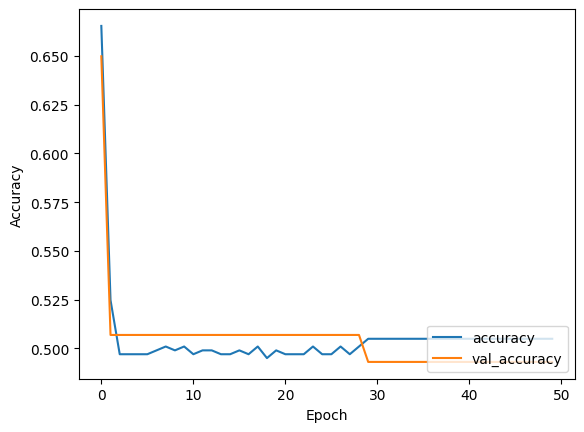

In [25]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

num_epochs = 50

X_train, X_test, y_train, y_test = reload8k()

model = models.Sequential(
    [
        layers.Conv1D(128, 3, activation="relu", input_shape=(X_train.shape[1], 1)),
        layers.MaxPooling1D(2),
        layers.Conv1D(32, 3, activation="relu"),
        layers.Dropout(0.4),
        layers.MaxPooling1D(2),
        layers.Conv1D(4, 3, activation="relu"),
        layers.MaxPooling1D(2),
        layers.Flatten(),
        layers.Dense(4, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ]
)


model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

history = model.fit(X_train, y_train, epochs=num_epochs, validation_data=(X_test, y_test))

plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.show()

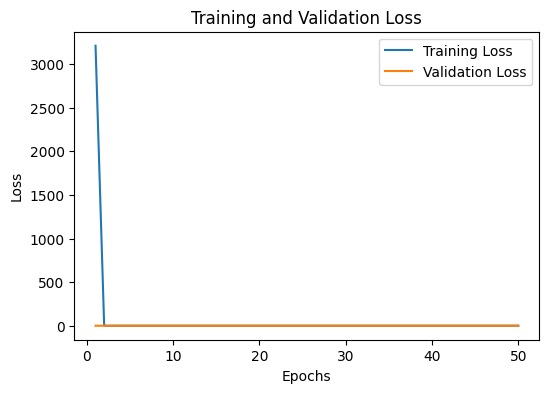

In [26]:
train_loss = history.history['loss']
val_loss = history.history['val_loss']


plt.figure(figsize=(6, 4))
plt.plot(range(1, 50+1), train_loss, label='Training Loss')
plt.plot(range(1, 50+1), val_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

(217, 8000)
7/7 [==============================] - 0s 61ms/step
0.4930875576036866


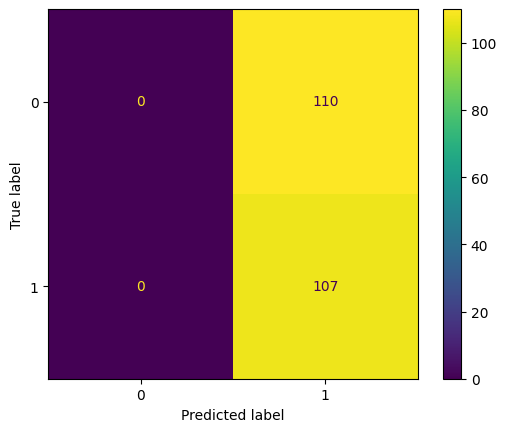

In [27]:
from sklearn.metrics import accuracy_score


print(X_test.shape)
y_pred = model.predict(X_test)
y_pred = np.where(y_pred > 0.5, 1, 0)
print(accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

In [6]:
color_list = [
    (144, 238, 144),   # Light Green
    (60, 179, 113),
    (34, 139, 34),
    (0, 128, 0),       # Green
    (0, 0, 255),       # Blue
    (30, 144, 255),
    (0, 0, 128),       # Dark Blue
    (255, 0, 0),       # Red
    (165, 42, 42),
    (139, 0, 0)        # Dark Red
]
# size 10

In [ ]:
color_list = [
    # Blue to Green
    (0, 0, 255), (0, 0, 239),  (0, 0, 223), (0, 0, 215), (0, 0, 199), (0, 0, 191), (0, 0, 183),
    (0, 0, 175), (0, 0, 159), (0, 0, 151), (0, 0, 135), (0, 0, 127), (0, 0, 119), (0, 0, 103),
    (0, 0, 95), (0, 0, 87), (0, 0, 79), (0, 0, 63), (0, 0, 55), (0, 0, 47), (0, 0, 31), (0, 0, 23),
    (0, 0, 15), (0, 0, 7), (0, 8, 0), (0, 16, 0), (0, 24, 0), (0, 32, 0), (0, 40, 0), (0, 48, 0), (0, 56, 0), (0, 64, 0),
    (0, 72, 0), (0, 80, 0), (0, 88, 0), (0, 96, 0), (0, 104, 0),  (0, 120, 0), (0, 128, 0), (0, 136, 0), 
    (0, 152, 0), (0, 168, 0), (0, 176, 0), (0, 192, 0), (0, 200, 0), (0, 208, 0),  (0, 224, 0),
    (0, 232, 0), (0, 240, 0), (0, 248, 0), (0, 255, 0),
    # Green to Yellow
    (127, 255, 0), (143, 255, 0), (159, 255, 0), (175, 255, 0), (191, 255, 0), (207, 255, 0), (223, 255, 0), (239, 255, 0), (255, 255, 0),
    # Yellow to Orange
    (255, 191, 0), (255, 175, 0), (255, 159, 0), (255, 143, 0), (255, 127, 0), (255, 111, 0), (255, 95, 0), (255, 79, 0), (255, 63, 0),
    (255, 47, 0), (255, 31, 0),
    # Orange to Red
    (255, 15, 0), (255, 31, 0), (255, 47, 0), (255, 63, 0), (255, 79, 0), (255, 111, 0), (255, 127, 0), (255, 143, 0),
    (255, 159, 0), (255, 175, 0), (255, 191, 0), (255, 207, 0), (255, 223, 0),  (255, 255, 0), (239, 255, 0), (223, 255, 0),
    (207, 255, 0), (191, 255, 0), (175, 255, 0), (159, 255, 0), (143, 255, 0),  (111, 255, 0), (95, 255, 0), (79, 255, 0),
    (63, 255, 0), (47, 255, 0), (31, 255, 0), (15, 255, 0), (0, 255, 0)
]


In [ ]:
color_list = [
    (0, 0, 255),    # Blue
    (0, 85, 170),
    (0, 170, 85),
    (0, 255, 0),    # Green
    (170, 170, 0),
    (255, 85, 0),
    (255, 255, 0),  # Yellow
    (255, 170, 0),
    (255, 85, 0),
    (255, 0, 0)     # Red
]


In [ ]:
# Generate a 100 list of BGR tuples transitioning through the color spectrum blue, green and red

blue = 255
green = 0
red = 0

color_list = []

for i in range(100):
    if blue > 0 and red == 0:
        blue -= 5
        green += 5
    if green > 0 and blue == 0:
        green -= 5
        red += 5
    if red > 0 and green == 0:
        blue += 5
        red -= 5
    color_list.append((blue, green, red))


(8000,)


/home/mbulucay/.local/lib/python3.10/site-packages/obspy/imaging/util.py:266: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 30.
  plt.setp(ax.get_xticklabels(), fontsize='small')
/home/mbulucay/.local/lib/python3.10/site-packages/obspy/imaging/waveform.py:815: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 30.
  plt.setp(ax.get_xticklabels(), fontsize='small',


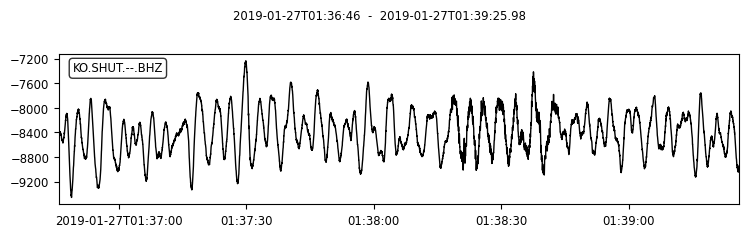

250
(8000,)


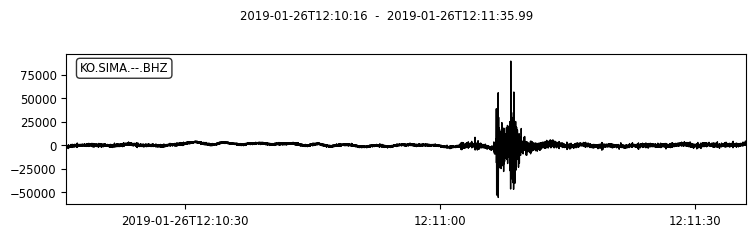

(250,)


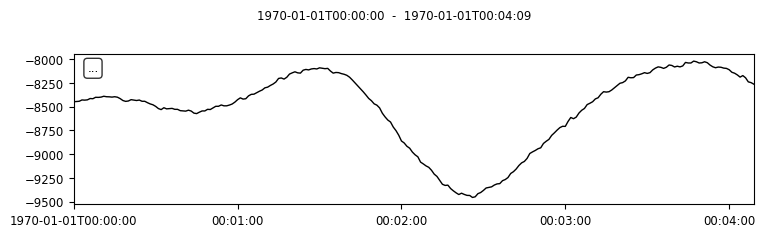

(1, 8000)
8000
1/1 [==============================] - 0s 15ms/step
1.00000, 0 250
1/1 [==============================] - 0s 19ms/step
1.00000, 250 500
1/1 [==============================] - 0s 14ms/step
1.00000, 500 750
1/1 [==============================] - 0s 13ms/step
1.00000, 750 1000
1/1 [==============================] - 0s 14ms/step
1.00000, 1000 1250
1/1 [==============================] - 0s 14ms/step
1.00000, 1250 1500
1/1 [==============================] - 0s 16ms/step
1.00000, 1500 1750
1/1 [==============================] - 0s 21ms/step
1.00000, 1750 2000
1/1 [==============================] - 0s 16ms/step
1.00000, 2000 2250
1/1 [==============================] - 0s 15ms/step
1.00000, 2250 2500
1/1 [==============================] - 0s 15ms/step
1.00000, 2500 2750
1/1 [==============================] - 0s 16ms/step
1.00000, 2750 3000
1/1 [==============================] - 0s 15ms/step
1.00000, 3000 3250
1/1 [==============================] - 0s 15ms/step
1.00000, 3250 3500


In [16]:
from obspy import read, Trace
import numpy as np

divide_number = 16

path0 = "./dataset8k_v2/class1/original/201901_10_62__SHUT.BHZ.KO_original.sac"
trace0 = read(path0)[0]
print(trace0.data.shape)
trace0.plot()

yummydata = np.array(trace0.data[:len(trace0.data) // divide_number])
print(len(yummydata))

path = "./dataset4k/class1/201901_14_29_KCTX.BHZ.SAC"
# path = "./dataset4k/class2/201901_20_37_TVSB.BHZ.SAC"
# path = "./dataset4k/class5/201903_14_0_SIMA.BHZ.SAC"
# path = "./dataset4k/class7/201901_20_0_SIMA.BHZ.SAC"
# path = "./dataset4k/class8/201911_3_1_SIMA.BHZ.SAC"
path = "./dataset8k_v2/class7/original/201901_17_0__SIMA.BHZ.KO_original.sac"

trace = read(path)[0]
print(trace.data.shape)
trace.plot()

tmp = Trace(data = yummydata)
print(tmp.data.shape)
tmp.plot()


predict_data = trace.data.reshape((1, len(trace.data)))
print(predict_data.shape)
print(len(predict_data[0]))

y_pred = model.predict(predict_data)
for y_val in y_pred:
  print( "%.5f" % float(y_val), end = ", ")

pred_list = []

for i in range(divide_number):
    start_index = i * (len(predict_data[0]) // divide_number)
    end_index = (i + 1) * (len(predict_data[0]) // divide_number)

    print(str(start_index) + " " + str(end_index))

    # Protect the original data by making a copy
    original_data = predict_data.copy()

    # Replace the section of predict_data with yummydata
    predict_data[0, start_index:end_index] = yummydata[:]

    pl = Trace(data = predict_data[0])
    # pl.plot()

    # # Perform the prediction on the modified predict_data
    y_pred = model.predict(predict_data)
    for y_val in y_pred[0]:
        print("%.5f" % float(y_val), end=", ")
        pred_list.append(float(y_val))

    # # Restore the original data
    predict_data = original_data.copy()


trace = Trace(data = predict_data[0])
# trace.plot()
trace.plot(outfile='trace_image.png')
print(pred_list)




In [17]:
import cv2
  
image = cv2.imread('trace_image.png')
overlay = image.copy()

# image sizes
print(overlay.shape)
  
# Rectangle parameters
x, y, w, h = 80, 60, 680, 150

rect_with_offset = w // divide_number

for i in range(divide_number):
    color_index = (100 - int(pred_list[i] * 100)) // (100 // len(color_list))
    print(color_index)
    
    # if y_pred > 0.5:
    overlay = cv2.rectangle(overlay, (x + i * rect_with_offset, y), (x + (i + 1) * rect_with_offset, y + h), color_list[color_index], -1)
    # else:
    #     overlay = cv2.rectangle(overlay, (x + i * rect_with_offset, y), (x + (i + 1) * rect_with_offset, y + h), color_list[len(color_list) - color_index], -1)

    # overlay = cv2.putText(overlay, str(i), (x + i * rect_with_offset, y - 2), cv2.FONT_HERSHEY_SIMPLEX, 1.3, (0, 0, 255), 2, cv2.LINE_AA)
    # overlay = cv2.putText(overlay, str(pred_list[i])[:4], (x + i * rect_with_offset + 30, y - 2), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 2, cv2.LINE_AA)


# A filled rectangle
# cv2.rectangle(overlay, (x, y), (x+w, y+h), (0, 200, 0), -1)  
  
alpha = 0.5  # Transparency factor.
# Following line overlays transparent rectangle
# over the image
image_new = cv2.addWeighted(overlay, alpha, image, 1 - alpha, 0)

cv2.imwrite("attention_signal.jpg", image_new)

cv2.imshow("some", image_new)
cv2.waitKey(0)
  
cv2.destroyAllWindows()

(250, 800, 3)
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
